#DATA

In [1]:
from torchvision.datasets import EuroSAT
import torch
from torchvision.transforms import v2
torch.manual_seed(1502)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE USED:", device)

DEVICE USED: cuda


Wrapper to transform only training data

In [2]:
from torch.utils.data import Dataset

class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        return self.transform(x), y

    def __len__(self):
        return len(self.subset)



In [3]:
from torch.utils.data import random_split

main_tf = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)])

data = EuroSAT(root="data", download=True, transform=main_tf)
train_data, test_data = random_split(data, lengths=[0.8, 0.2])

In [4]:
train_data_tensor = torch.stack([img for img, _ in train_data])
mean = train_data_tensor.mean(dim=(0,2,3)).tolist()
std = train_data_tensor.std(dim=(0,2,3)).tolist()

In [5]:
train_tf = v2.Compose([
    v2.RandomVerticalFlip(),
    v2.RandomHorizontalFlip(),
    v2.RandomErasing(scale=[0.01, 0.33])
    ])

main_tf = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std)
    ])

train_data = TransformSubset(train_data, train_tf)
data.transform = main_tf

In [6]:
print("IMAGE SIZE:", data[1][0].shape)
print(f"CLASSES ({len(data.classes)}): {data.classes}")

IMAGE SIZE: torch.Size([3, 64, 64])
CLASSES (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


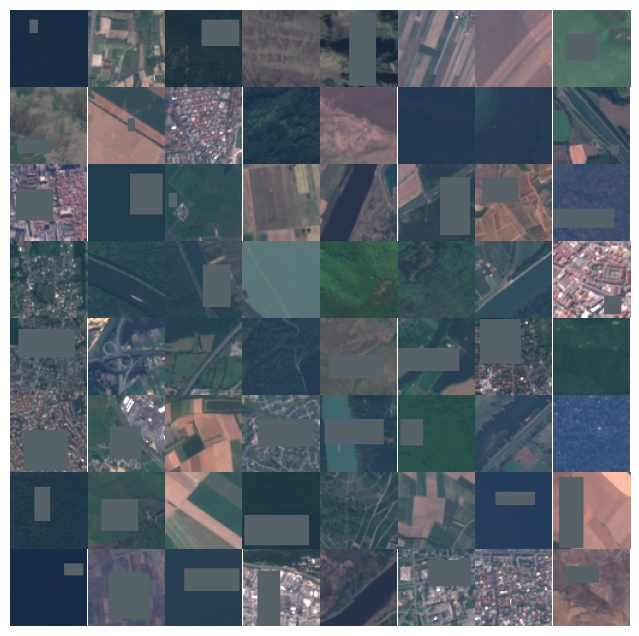

In [7]:
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

mean_t = torch.tensor(mean).view(3, 1, 1)
std_t = torch.tensor(std).view(3, 1, 1)

D = 8

class_names = data.classes
fig, ax = plt.subplots(D,D,figsize=(8,8))
fig.subplots_adjust(wspace=0, hspace=0)
k = torch.randint(1, 2000, (1,)).item()
for i in range(D):
    for j in range(D):
        image, label = train_data[k]
        image = (image * std_t + mean_t).clamp(0, 1)
        ax[i, j].imshow(to_pil_image(image))
        ax[i,j].axis(False)
        ax[i, j].padding = 0
        k += 1
        ax[i, j].plot()


#Setting up training
Setting up training variables and functions

In [8]:
from torch.utils.data import DataLoader
import torch
EPOCHS = 30
BATCH_SIZE = 32
W_DECAY = 0.00001
LR = 2.5e-5
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

In [9]:
from sklearn.metrics import accuracy_score

def train_step(model: torch.nn.Module, data_loader, loss_fn, optimizer,):
     loss_total = 0
     acc_total = 0
     model.train()
     for X, y in data_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss_total += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        acc_total += accuracy_score(y.cpu(), y_pred.cpu().argmax(dim=1))
     loss_total /= len(data_loader)
     acc_total /= len(data_loader)
     return {"Loss": loss_total.item(), "Acc": acc_total}

def test_step(model: torch.nn.Module, data_loader, loss_fn):
    loss_total = 0
    acc_total = 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            loss_total += loss
            acc_total += accuracy_score(y.cpu(), y_pred.cpu().argmax(dim=1))
        loss_total /= len(data_loader)
        acc_total /= len(data_loader)
        return {"Loss": loss_total.item(), "Acc": acc_total}

import matplotlib.pyplot as plt

def plotting(train_loss, train_acc, test_loss, test_acc):
    fig, ax = plt.subplots(1,2, figsize=(8,4))
    ax[0].plot(train_loss)
    ax[0].plot(test_loss)
    ax[0].set_title("LOSS")
    ax[1].plot(train_acc)
    ax[1].plot(test_acc)
    ax[1].set_title("ACCURACY")
    return ax

# Basic model
Here I try to use the same model as FashionMNIST to EuroSAT and evaluate perfomance

In [10]:
from torch import nn
from torchvision import transforms

class ConvBlock(nn.Module):
  def __init__(self, input_shape, hidden_units):
    """
    Passes X through two conv layer, batch, Relu, twice and ends with maxPool
    """
    super().__init__()
    self.conv_block = nn.Sequential(
                nn.Conv2d(in_channels=input_shape,
                            out_channels=hidden_units,
                            kernel_size=3,
                            stride=1,
                            padding=1),
                nn.BatchNorm2d(num_features=hidden_units),
                nn.ReLU(),
                nn.Conv2d(in_channels=hidden_units,
                            out_channels=hidden_units,
                            kernel_size=3,
                            stride=1,
                            padding=1),
                nn.BatchNorm2d(num_features=hidden_units),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2))

  def forward(self, x):
    return self.conv_block(x)

class ConvClassifier(nn.Module):
  #Flattens and classifies conv layer output
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(in_features=input_shape,
                          out_features=hidden_units),
                nn.Dropout(p=0.2),
                nn.Linear(in_features=hidden_units,
                          out_features=output_shape))
    def forward(self, x):
        return self.classifier(x)

class FashionClassifier(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.conv_block_1 = ConvBlock(input_shape=input_shape, hidden_units=hidden_units)
        self.conv_block_2 = ConvBlock(input_shape=hidden_units, hidden_units=hidden_units*2)
        self.classifier_layer = ConvClassifier(input_shape=hidden_units*2*16*16, hidden_units=128, output_shape=output_shape)

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier_layer(x)
        return x

In [11]:
model = FashionClassifier(input_shape=3, hidden_units=15, output_shape=len(class_names)).to(device)

  3%|▎         | 1/30 [00:29<14:13, 29.44s/it]

EPOCH: 0 
 TRAIN Loss: 1.209646224975586 
 TEST Loss: 0.7946085929870605
 TEST Acc: 72.70%


  7%|▋         | 2/30 [00:57<13:18, 28.53s/it]

EPOCH: 1 
 TRAIN Loss: 0.8723198771476746 
 TEST Loss: 0.6817286014556885
 TEST Acc: 76.06%


 10%|█         | 3/30 [01:25<12:42, 28.24s/it]

...

EPOCH: 27 
 TRAIN Loss: 0.40964365005493164 
 TEST Loss: 0.37598398327827454
 TEST Acc: 87.37%


 97%|█████████▋| 29/30 [13:34<00:28, 28.04s/it]

EPOCH: 28 
 TRAIN Loss: 0.3999972939491272 
 TEST Loss: 0.380637526512146
 TEST Acc: 87.09%


100%|██████████| 30/30 [14:02<00:00, 28.08s/it]

EPOCH: 29 
 TRAIN Loss: 0.4035760164260864 
 TEST Loss: 0.3730982542037964
 TEST Acc: 87.52%


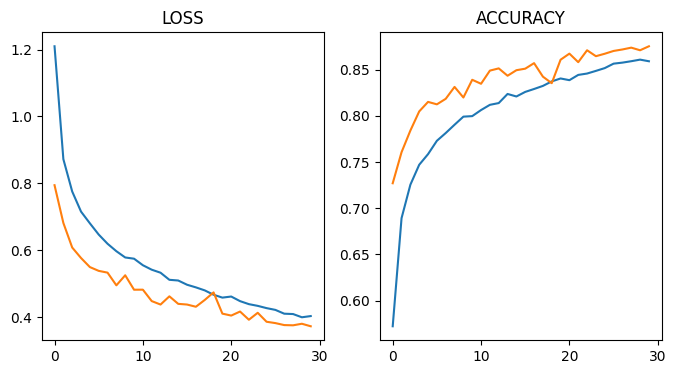

In [12]:
from tqdm import tqdm

epochs = EPOCHS
optimizer = torch.optim.AdamW(params=model.parameters(), lr=LR, weight_decay=W_DECAY)
loss_fn = nn.CrossEntropyLoss()
train_loss_list = list()
test_loss_list = list()
train_acc_list = list()
test_acc_list = list()

for epoch in tqdm(range(epochs)):
    res_train = train_step(model=model,
                           data_loader=train_dataloader,
                           loss_fn=loss_fn,
                           optimizer=optimizer)
    res_test = test_step(model=model,
                           data_loader=test_dataloader,
                           loss_fn=loss_fn)

    train_loss_list.append(res_train['Loss'])
    train_acc_list.append(res_train["Acc"])
    test_loss_list.append(res_test['Loss'])
    test_acc_list.append(res_test['Acc'])

    print(f"EPOCH: {epoch} \n TRAIN Loss: {res_train['Loss']} \n TEST Loss: {res_test['Loss']}\n TEST Acc: {res_test['Acc']*100:.2f}%")

axes = plotting(train_loss_list, train_acc_list, test_loss_list, test_acc_list)
for ax in axes: ax.plot()

#GoogLeNet

In [13]:
from torch.nn.modules.dropout import Dropout
from torch.nn.modules.pooling import MaxPool2d
from torch import nn

class Head1(nn.Module):
    """
    1x1conv, ReLU
    HXW unchanged
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels=self.in_channels,
                out_channels=self.out_channels,
                kernel_size=1
                ),
            nn.BatchNorm2d(
                num_features=self.out_channels
            ),
            nn.ReLU()
        )

    def forward(self, x): return self.conv(x)

class Head2(nn.Module):
    """
    1x1conv, ReLU, 3x3conv, ReLU
    HXW unchanged
    """
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.hidden_channels = hidden_channels
        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels=self.in_channels,
                out_channels=self.hidden_channels,
                kernel_size=1
            ),
            nn.BatchNorm2d(
                num_features=self.hidden_channels
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=self.hidden_channels,
                out_channels=self.out_channels,
                kernel_size=3,
                padding=1
                ),
            nn.BatchNorm2d(
                num_features=self.out_channels
            ),
            nn.ReLU()
        )

    def forward(self, x): return self.conv(x)

class Head3(nn.Module):
    """
    1x1conv, ReLU, 5x5conv, ReLU
    HXW unchanged
    """
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.hidden_channels = hidden_channels
        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels=self.in_channels,
                out_channels=self.hidden_channels,
                kernel_size=1
            ),
            nn.BatchNorm2d(
                num_features=self.hidden_channels,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=self.hidden_channels,
                out_channels=self.out_channels,
                kernel_size=5,
                padding=2
                ),
            nn.BatchNorm2d(
                num_features=self.out_channels
            ),
            nn.ReLU()
        )

    def forward(self, x): return self.conv(x)

class Head4(nn.Module):
    """
    MaxPool, 1x1conv, ReLU
    HXW unchanged
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.conv = nn.Sequential(
            nn.MaxPool2d(
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.Conv2d(
                in_channels=self.in_channels,
                out_channels=self.out_channels,
                kernel_size=1
                ),
            nn.BatchNorm2d(
                num_features=self.out_channels
            ),
            nn.ReLU()
        )

    def forward(self, x): return self.conv(x)

class Inception(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.head1 = Head1(in_channels, out_channels//4)
        self.head2 = Head2(in_channels, hidden_channels, out_channels//4)
        self.head3 = Head3(in_channels, hidden_channels, out_channels//4)
        self.head4 = Head4(in_channels, out_channels//4)

    def forward(self, x):
        x1 = self.head1(x)
        x2 = self.head2(x)
        x3 = self.head3(x)
        x4 = self.head4(x)
        return torch.cat((x1, x2, x3, x4), dim=1)

class GoogLeNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=32,
                kernel_size=5
            ),
            nn.BatchNorm2d(
                num_features=32
            ),
            nn.MaxPool2d(
                kernel_size=2
            ),
            nn.Conv2d(
                in_channels=32,
                out_channels=32,
                kernel_size=1
            ),
            nn.Conv2d(
                in_channels=32,
                out_channels=96,
                kernel_size=3
            ),
            nn.BatchNorm2d(
                num_features=96
            ),
            nn.MaxPool2d(
                kernel_size=2
            )
        )

        self.inceptionA = nn.Sequential(
            Inception(
                in_channels=96,
                hidden_channels=96,
                out_channels=128
            ),
            Inception(
                in_channels=128,
                hidden_channels=128,
                out_channels=128
            )
        )

        self.max = nn.MaxPool2d(kernel_size=2)

        self.inceptionB = nn.Sequential(
            Inception(
                in_channels=128,
                hidden_channels=128,
                out_channels=256
                ),
            Inception(
                in_channels=256,
                hidden_channels=256,
                out_channels=512
                )
        )

        self.classification = nn.Sequential(
            nn.AdaptiveAvgPool2d(output_size=1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(in_features=512,
                      out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128,
                      out_features=out_channels)
        )

    def forward(self, x):
        x = self.block(x)
        x = self.inceptionA(x)
        x = self.max(x)
        x = self.inceptionB(x)
        x = self.classification(x)
        return x


In [14]:
model = GoogLeNet(in_channels=3 , out_channels=len(class_names)).to(device)

  3%|▎         | 1/30 [00:38<18:32, 38.37s/it]

EPOCH: 0 
 TRAIN Loss: 1.1801807880401611 
 TEST Loss: 0.6165424585342407
 TEST Acc: 79.54%


  7%|▋         | 2/30 [01:16<17:51, 38.26s/it]

EPOCH: 1 
 TRAIN Loss: 0.6862215399742126 
 TEST Loss: 0.4569411873817444
 TEST Acc: 84.82%


 10%|█         | 3/30 [01:55<17:16, 38.39s/it]

...

EPOCH: 27 
 TRAIN Loss: 0.19460518658161163 
 TEST Loss: 0.16332383453845978
 TEST Acc: 94.46%


 97%|█████████▋| 29/30 [18:28<00:38, 38.10s/it]

EPOCH: 28 
 TRAIN Loss: 0.176327645778656 
 TEST Loss: 0.1574082225561142
 TEST Acc: 94.96%


100%|██████████| 30/30 [19:06<00:00, 38.22s/it]

EPOCH: 29 
 TRAIN Loss: 0.18547341227531433 
 TEST Loss: 0.14437679946422577
 TEST Acc: 95.30%


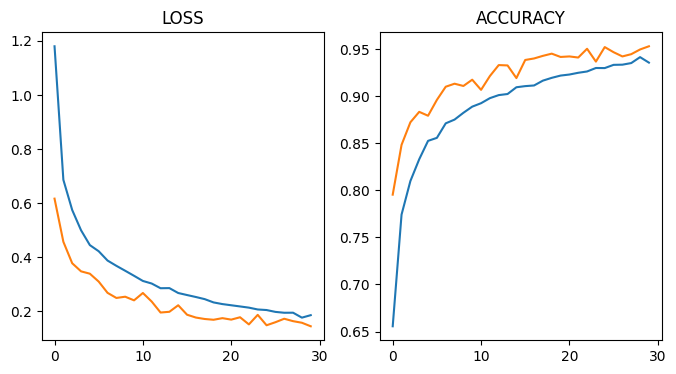

In [15]:
from tqdm import tqdm

epochs = EPOCHS
optimizer = torch.optim.AdamW(params=model.parameters(), lr=LR, weight_decay=W_DECAY)
loss_fn = nn.CrossEntropyLoss()
train_loss_list = list()
test_loss_list = list()
train_acc_list = list()
test_acc_list = list()

for epoch in tqdm(range(epochs)):
    res_train = train_step(model=model,
                           data_loader=train_dataloader,
                           loss_fn=loss_fn,
                           optimizer=optimizer)
    res_test = test_step(model=model,
                           data_loader=test_dataloader,
                           loss_fn=loss_fn)

    train_loss_list.append(res_train['Loss'])
    train_acc_list.append(res_train["Acc"])
    test_loss_list.append(res_test['Loss'])
    test_acc_list.append(res_test['Acc'])

    print(f"EPOCH: {epoch} \n TRAIN Loss: {res_train['Loss']} \n TEST Loss: {res_test['Loss']}\n TEST Acc: {res_test['Acc']*100:.2f}%")

axes = plotting(train_loss_list, train_acc_list, test_loss_list, test_acc_list)
for ax in axes: ax.plot()

#ResNet

In [17]:
from torch import nn

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(
                num_features=out_channels
            ),
            nn.ReLU(),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                stride=1,
                bias=False
            ),
            nn.BatchNorm2d(
                num_features=out_channels
            ),
            nn.ReLU()
        )

        self.res = nn.Sequential()
        if stride > 1 or out_channels != in_channels:
            self.res = nn.Sequential(
                    nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(
                    num_features=out_channels
                )
            )

    def forward(self, x):
        return self.block(x) + self.res(x)



class ResNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.ResNet = nn.Sequential(
            self.make_layer(
                in_channels=in_channels,
                out_channels=64,
                block=ResBlock,
                n_blocks=2,
                stride=1),
            self.make_layer(
                in_channels=64,
                out_channels=128,
                block=ResBlock,
                n_blocks=2,
                stride=2),
            self.make_layer(
                in_channels=128,
                out_channels=256,
                block=ResBlock,
                n_blocks=2,
                stride=2),
            self.make_layer(
                in_channels=256,
                out_channels=512,
                block=ResBlock,
                n_blocks=2,
                stride=2)
        )

        self.classification = nn.Sequential(
            nn.AdaptiveAvgPool2d(output_size=1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(
                in_features=512,
                out_features=256,
            ),
            nn.ReLU(),
            nn.Linear(
                in_features=256,
                out_features=out_channels
            )
        )

    def make_layer(self, in_channels, out_channels, block, stride, n_blocks):
        strides = [stride] + [1]*(n_blocks-1)
        layers = list()
        block_in_channels = in_channels
        for stride in strides:
            layers.append(block(block_in_channels, out_channels, stride))
            block_in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.ResNet(x)
        return self.classification(x)


In [18]:
model = ResNet(in_channels=3 , out_channels=len(class_names)).to(device)

  3%|▎         | 1/30 [00:38<18:25, 38.12s/it]

EPOCH: 0 
 TRAIN Loss: 1.0006804466247559 
 TEST Loss: 0.5909615159034729
 TEST Acc: 78.88%


  7%|▋         | 2/30 [01:16<17:45, 38.07s/it]

EPOCH: 1 
 TRAIN Loss: 0.6486154198646545 
 TEST Loss: 0.4833502173423767
 TEST Acc: 83.40%


 10%|█         | 3/30 [01:54<17:07, 38.05s/it]

...

EPOCH: 27 
 TRAIN Loss: 0.1112867146730423 
 TEST Loss: 0.11280758678913116
 TEST Acc: 96.22%


 97%|█████████▋| 29/30 [18:17<00:37, 37.88s/it]

EPOCH: 28 
 TRAIN Loss: 0.11383054405450821 
 TEST Loss: 0.09934620559215546
 TEST Acc: 96.84%


100%|██████████| 30/30 [18:55<00:00, 37.84s/it]

EPOCH: 29 
 TRAIN Loss: 0.10450121760368347 
 TEST Loss: 0.12435891479253769
 TEST Acc: 96.00%


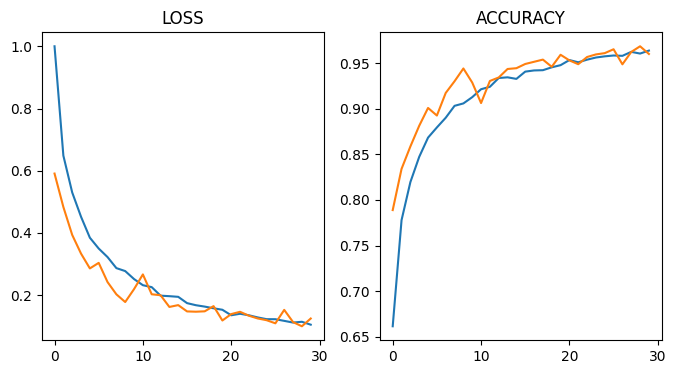

In [19]:
from tqdm import tqdm

epochs = EPOCHS
optimizer = torch.optim.AdamW(params=model.parameters(), lr=LR, weight_decay=W_DECAY)
loss_fn = nn.CrossEntropyLoss()
train_loss_list = list()
test_loss_list = list()
train_acc_list = list()
test_acc_list = list()

for epoch in tqdm(range(epochs)):
    res_train = train_step(model=model,
                           data_loader=train_dataloader,
                           loss_fn=loss_fn,
                           optimizer=optimizer)
    res_test = test_step(model=model,
                           data_loader=test_dataloader,
                           loss_fn=loss_fn)

    train_loss_list.append(res_train['Loss'])
    train_acc_list.append(res_train["Acc"])
    test_loss_list.append(res_test['Loss'])
    test_acc_list.append(res_test['Acc'])

    print(f"EPOCH: {epoch} \n TRAIN Loss: {res_train['Loss']} \n TEST Loss: {res_test['Loss']}\n TEST Acc: {res_test['Acc']*100:.2f}%")

axes = plotting(train_loss_list, train_acc_list, test_loss_list, test_acc_list)
for ax in axes: ax.plot()

#DenseNet



In [21]:
from torch import nn
import torch


class DenseBlock(nn.Module):
    def __init__(self, in_channels, k, n_layers):
        """
        Returns k*n_layers+channels channels
        """
        super().__init__()
        layers = list()
        self.in_channels = in_channels
        self.k = k

        for i in range(n_layers):
            layers.append(
                self.make_block(
                    in_channels=self.in_channels,
                    out_channels=self.k
                )
            )
            self.update_in_channels()
        self.layers = nn.Sequential(*layers)

    def make_block(self, in_channels, out_channels):
        return nn.Sequential(
                    nn.BatchNorm2d(
                        num_features=in_channels
                    ),
                    nn.ReLU(),
                    nn.Conv2d(
                        in_channels=in_channels,
                        out_channels=out_channels,
                        kernel_size=3,
                        padding=1
                    )
                )

    def update_in_channels(self):
        self.in_channels = self.k+self.in_channels

    def forward(self, x):
        for layers in self.layers:
            y = layers(x)
            x = torch.concat([y, x], dim=1)
        return x

class Conv(nn.Module):
    """
    3x3 conv, BatchNorm, MaxPool
    HxW = (HxW)/2
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                padding=1,
                stride=1
            ),
            nn.BatchNorm2d(
                num_features=out_channels
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

    def forward(self, x):
        return self.conv(x)


class DenseNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_features, n_dense_layers, n_dense_blocks, k):
        super().__init__()

        self.hidden_channels=hidden_channels
        self.n_dense_layers=n_dense_layers
        self.k = k

        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=self.hidden_channels,
                kernel_size=7,
                padding=3
            ),
            nn.BatchNorm2d(
                num_features=self.hidden_channels
            ),
            nn.ReLU()
        )

        body = list()

        for i in range(n_dense_blocks):
            body.append(
                self.make_block(
                    in_channels=self.hidden_channels,
                    n_dense_layers=self.n_dense_layers,
                    k=self.k
                )
            )
            self.update_hidden_channels()
        body.append(
            nn.Sequential(
                nn.BatchNorm2d(self.hidden_channels),
                nn.ReLU()
            )
        )
        self.body = nn.Sequential(*body)

        self.classification = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(
                in_features=self.hidden_channels,
                out_features=256,
            ),
            nn.ReLU(),
            nn.Linear(
                in_features=256,
                out_features=out_features
            )
        )

    def make_block(self, in_channels, n_dense_layers, k):
        """
        Makes a block of a Dense block + convolution
        """
        return nn.Sequential(
            Conv(
                in_channels=in_channels,
                out_channels=in_channels
            ),
            DenseBlock(
                in_channels=in_channels,
                n_layers=n_dense_layers,
                k=self.k
            ),
            nn.Dropout2d(0.1)
        )


    def update_hidden_channels(self):
        self.hidden_channels = self.n_dense_layers*self.k+self.hidden_channels

    def forward(self, x):
        x = self.stem(x)
        x = self.body(x)
        return self.classification(x)


In [22]:
model = DenseNet(in_channels=3, hidden_channels=24, out_features=10, n_dense_layers=8, n_dense_blocks=3, k=16).to(device)

  3%|▎         | 1/30 [00:40<19:45, 40.88s/it]

EPOCH: 0 
 TRAIN Loss: 1.3658970594406128 
 TEST Loss: 0.8652259111404419
 TEST Acc: 70.45%


  7%|▋         | 2/30 [01:21<19:02, 40.79s/it]

EPOCH: 1 
 TRAIN Loss: 0.8397221565246582 
 TEST Loss: 0.6517037153244019
 TEST Acc: 77.10%


 10%|█         | 3/30 [02:02<18:22, 40.82s/it]

...

EPOCH: 27 
 TRAIN Loss: 0.24602559208869934 
 TEST Loss: 0.17583124339580536
 TEST Acc: 94.00%


 97%|█████████▋| 29/30 [19:44<00:40, 40.80s/it]

EPOCH: 28 
 TRAIN Loss: 0.24189206957817078 
 TEST Loss: 0.1731330007314682
 TEST Acc: 93.95%


100%|██████████| 30/30 [20:25<00:00, 40.83s/it]

EPOCH: 29 
 TRAIN Loss: 0.23498320579528809 
 TEST Loss: 0.16048742830753326
 TEST Acc: 94.50%


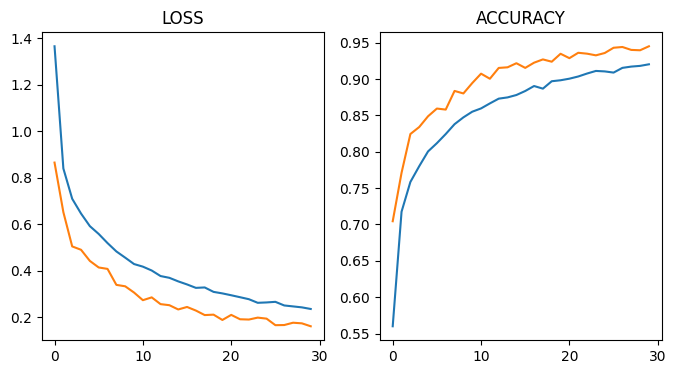

In [23]:
from tqdm import tqdm

epochs = EPOCHS
optimizer = torch.optim.AdamW(params=model.parameters(), lr=LR, weight_decay=W_DECAY)
loss_fn = nn.CrossEntropyLoss()
train_loss_list = list()
test_loss_list = list()
train_acc_list = list()
test_acc_list = list()

for epoch in tqdm(range(epochs)):
    res_train = train_step(model=model,
                           data_loader=train_dataloader,
                           loss_fn=loss_fn,
                           optimizer=optimizer)
    res_test = test_step(model=model,
                           data_loader=test_dataloader,
                           loss_fn=loss_fn)

    train_loss_list.append(res_train['Loss'])
    train_acc_list.append(res_train["Acc"])
    test_loss_list.append(res_test['Loss'])
    test_acc_list.append(res_test['Acc'])

    print(f"EPOCH: {epoch} \n TRAIN Loss: {res_train['Loss']} \n TEST Loss: {res_test['Loss']}\n TEST Acc: {res_test['Acc']*100:.2f}%")

axes = plotting(train_loss_list, train_acc_list, test_loss_list, test_acc_list)
for ax in axes: ax.plot()